# Samuel-3 stats

Use the Samuel-3 stroke data to create stats that will inform the synthetic data.

## Code setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker  # for axis ticks

## Load data

In [2]:
df = pd.read_csv('/home/anna/samuel3/data/cleaned_data_anon_teams(in).csv')

In [3]:
df['year'].describe()[['min', 'max']]

min    2020.0
max    2025.0
Name: year, dtype: float64

Relabel stroke teams:

In [4]:
make_teams = False
if make_teams:
    np.random.seed(42)
    
    team_keys = df['stroke_team'].unique()
    np.random.shuffle(team_keys)
    team_values = np.arange(len(team_keys))
    
    team_dict = dict(zip(team_keys, team_values))
    # Save a copy of this:
    pd.Series(team_dict).to_csv('./anon/teamlookup.csv')
else:
    team_dict = pd.read_csv('./anon/teamlookup.csv', index_col=0).squeeze().to_dict()

In [5]:
# Apply map to df:
df['stroke_team'] = df['stroke_team'].map(team_dict)

Remove large arrival times:

In [6]:
df = df[df['onset_to_arrival_time'] < 60*4]

## Simplify data

Change certain columns to make the data simpler.

| Column | Original | Simple |
| --- | --- | --- |
| Age | 5-year age bands | Over/under 80 (i.e. age band 77.5 is under, 82.5 is over) |
| Prior disability | mRS 0-5 inclusive | mRS<=2 |
| Arrival-to-scan time | Continuous, rounded to nearest minute | Under 30 minutes |
| Stroke team | Categorical, 116 options | ? |
| Stroke severity | Continuous, 0-42 inclusive | Mild (0-9), moderate (10-25), severe (26-42) |
| Discharge disability | mRS 0-6 inclusive | mRS<=2 |

Conversion from mRS score to utility (References: Wang et al. 2020: Stroke. 2020;51:2411–2417; Dijkland et al. 2018: Stroke. 2018;49:965–971)
| Name | mRS=0 | mRS=1 | mRS=2 | mRS=3 | mRS=4 | mRS=5 | mRS=6 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Wang2020 | 0.97 | 0.88 | 0.74 | 0.55 | 0.2 | -0.19 | 0 |
| Dijkland2018 | 0.95 | 0.93 | 0.83 | 0.62 | 0.42 | 0.11 | 0 |


In [7]:
df['age_over80'] = (df['age'] >= 80).astype(int)
df['prior_disability_leq2'] = (df['prior_disability'] <= 2).astype(int)
df['discharge_disability_leq2'] = (df['discharge_disability'] <= 2).astype(int)
df['arrival_to_scan_fast'] = (df['arrival_to_scan_time'] < 30) 
df['stroke_severity_mild'] = (df['stroke_severity'] < 10).astype(int)
df['stroke_severity_mod'] = ((df['stroke_severity'] >= 10) &
                             (df['stroke_severity'] <= 25)).astype(int)
df['stroke_severity_sev'] = (df['stroke_severity'] > 25).astype(int)

## Pick out data

In [8]:
cols_bar = ['stroke_team', 'stroke_severity', 'onset_during_sleep',
            'precise_onset_known', 'atrial_fibrillation',
            'afib_anticoagulant', 'prior_disability', 'thrombolysis',
            'discharge_disability', 'age',
            # Simplified columns:
            'age_over80', 'prior_disability_leq2', 'discharge_disability_leq2',
            'stroke_severity_mild', 'stroke_severity_mod', 'stroke_severity_sev',
           ]
cols_hist = ['arrival_to_scan_time']

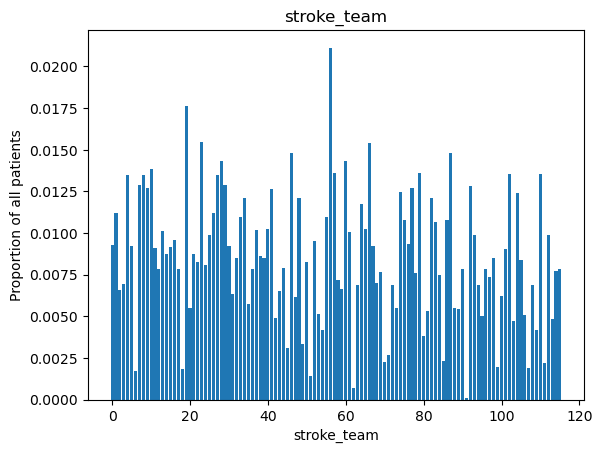

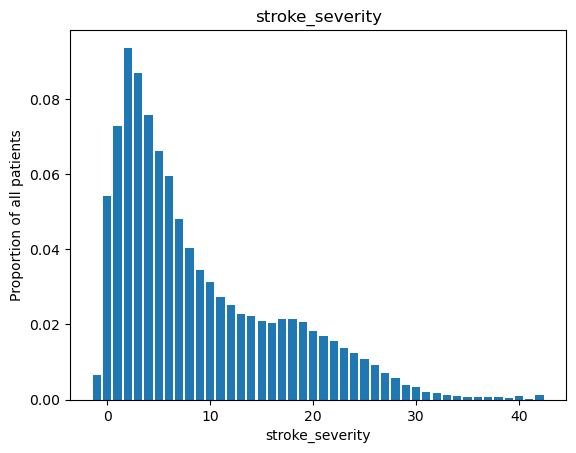

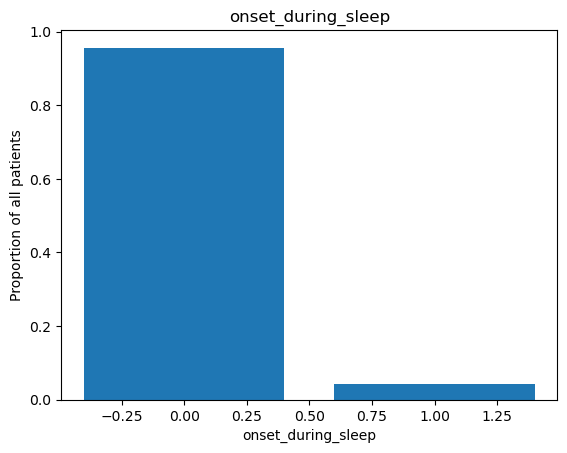

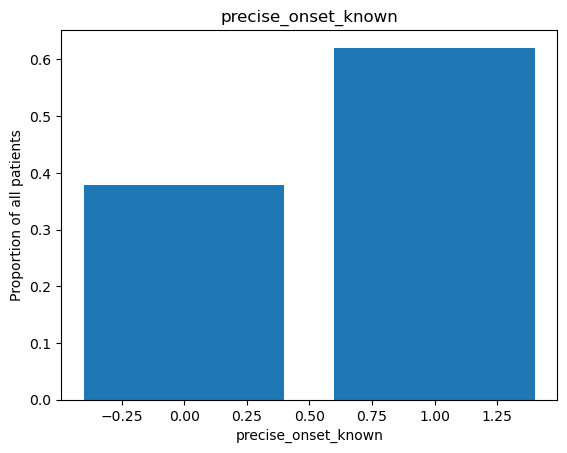

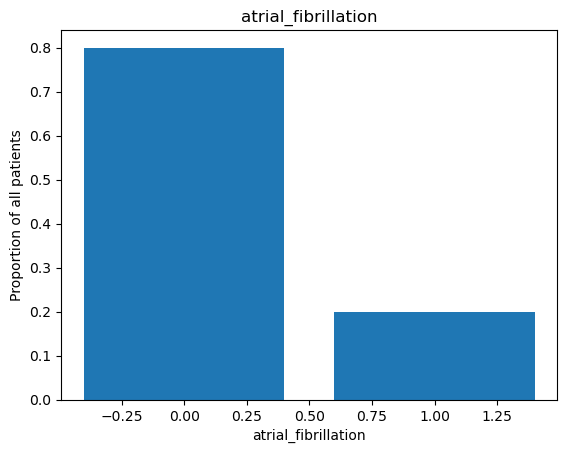

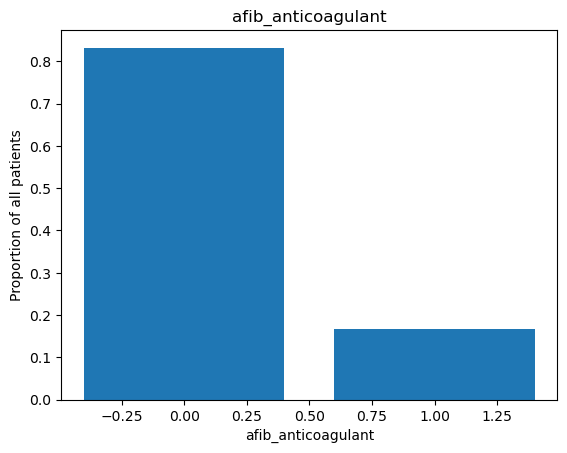

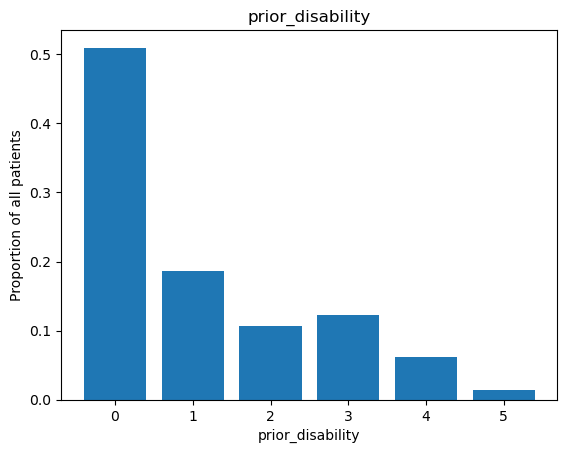

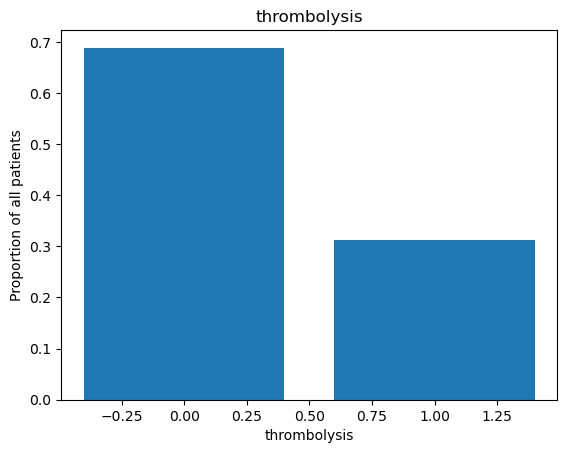

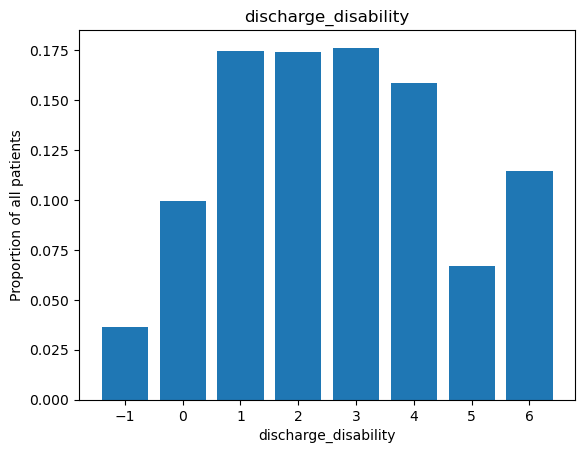

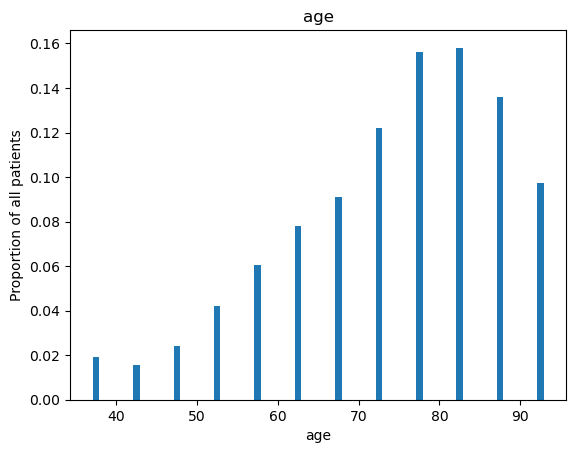

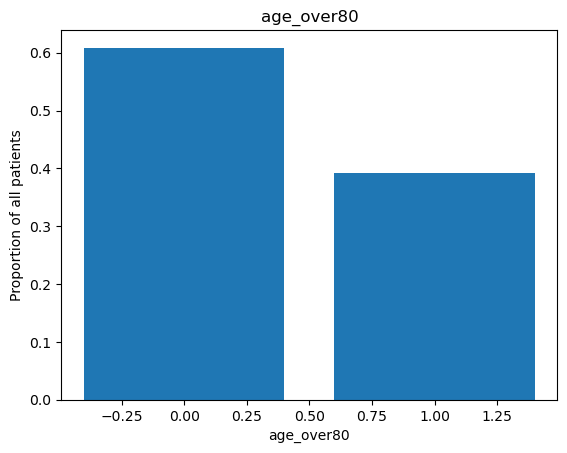

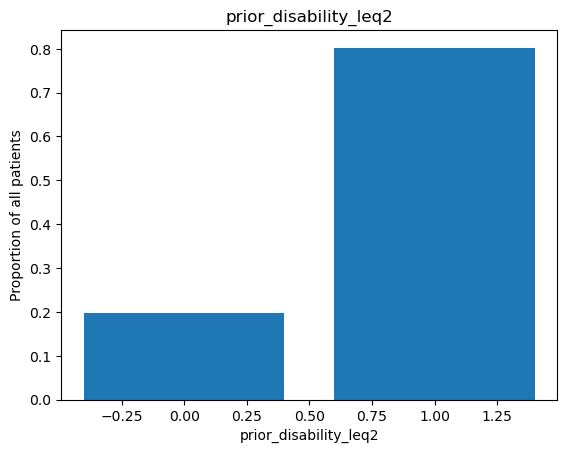

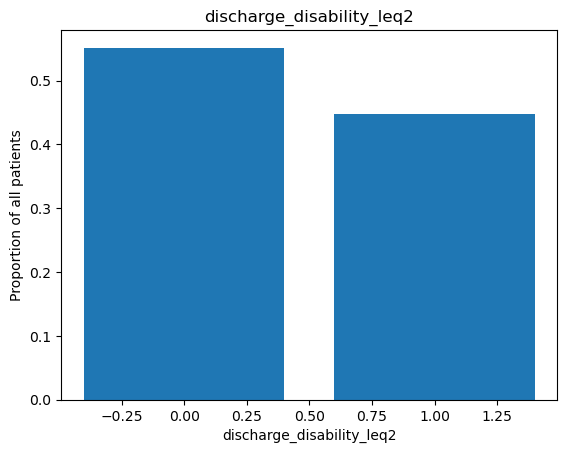

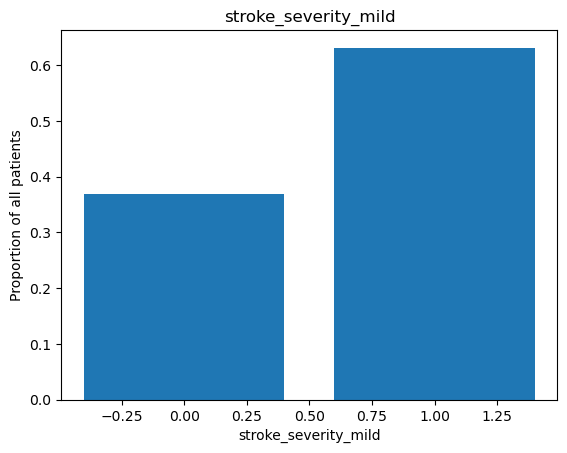

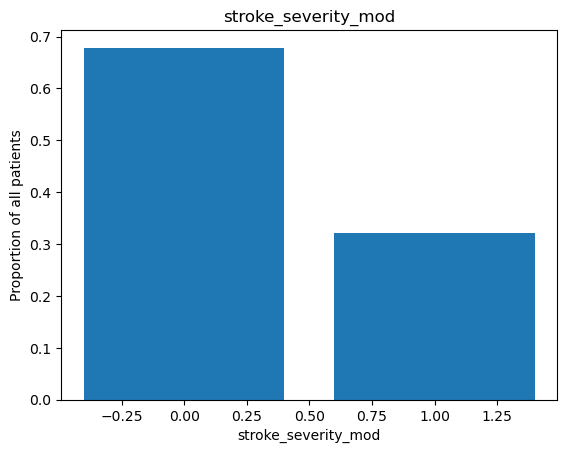

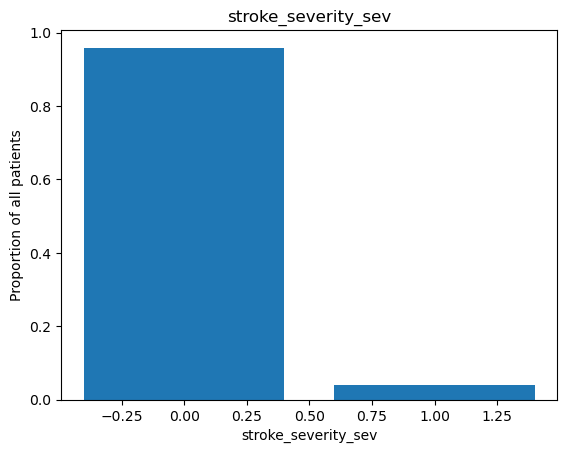

In [20]:
for col in cols_bar:
    
    b = df[col].value_counts(dropna=False)
    # Turn into proportion of patients:
    b = b / b.sum()
    if b.index.isna().any():
        # Mark missing:
        s = pd.Series(b.index)
        s[s.isna()] = -1
        b.index = s#.astype(object)

    # Round:
    b = b.round(5)
    # Check sum to 1:
    if b.sum() != 1:
        ind = b[b.notna()].index[-1]
        b.loc[ind] += (1.0 - b.sum())
    if b.sum() != 1:
        print('Check - ', col)
    
    # Save to file:
    b.to_csv(f'./summary_data/{col}.csv')
    
    plt.bar(b.index, b.values)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Proportion of all patients')
    plt.savefig(f'./images/{col}.png')
    plt.show()

Check -  arrival_to_scan_time


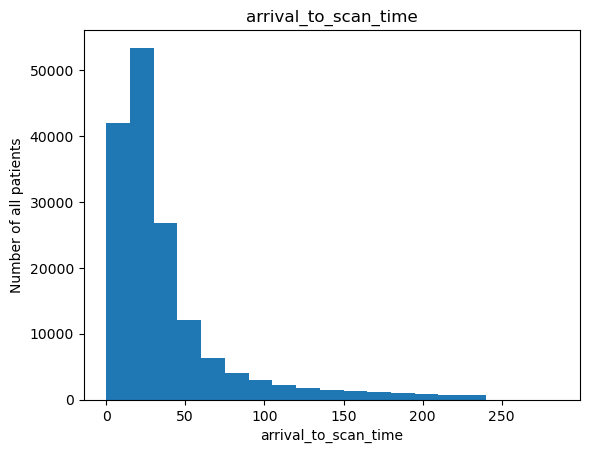

In [10]:
for col in cols_hist:
    v = df[col]
    # Remove ludicrous times:
    v = v[v < 4*60]

    # Histogram:
    heights, bins, _ = plt.hist(v, bins=np.arange(0, 4*60+60, 15))

    heights /= sum(heights)
    
    s = pd.DataFrame(np.array([bins[:-1], heights]).T, columns=['bin_edge', 'height'])
    s = s.set_index('bin_edge')['height']
    # Round:
    s = s.round(5)
    # Check sum to 1:
    if s.sum() != 1.0:
        ind = s[s.notna()].index[-1]
        s.loc[ind] += round(1.0 - s.sum(), 5)
        # s = s.round(5)
    if s.round(5).sum() != 1:
        print('Check - ', col)
        
    # Save to file:
    s.to_csv(f'./summary_data/{col}.csv')
    
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Number of all patients')
    plt.savefig(f'./images/{col}.png')
    plt.show()

## Compare the age and prior disability

In [9]:
def grid_overlap_two(df, col1, col2):
    """
    Convert two df column counts into a grid.

    df should contain two columns called col1 and col2.
    This finds how many rows of data have each combined values
    of col1 and col2.
    """
    # How many people are in each combo of values?
    df_g = df[[col1, col2]].value_counts()
    df_g.name = 'counts'
    
    # # Convert counts to proportion of all patients:
    # df_g = df_g / df_g.sum()
    
    # Convert list to grid:
    df_g = df_g.reset_index()
    df_g = df_g.pivot(columns=col1, index=col2, values='counts')
    return df_g

In [10]:
def draw_grid(df_g, col1, col2, savename=''):
    
    fig = plt.figure(figsize=(8, 4))
    c = plt.imshow(df_g, cmap='Blues', origin='lower')
    plt.colorbar(c, label='Proportion of patients')
    plt.yticks(range(len(df_g.index)), labels=df_g.index)
    plt.xticks(range(len(df_g.columns)), labels=df_g.columns)
    plt.ylabel(col2)
    plt.xlabel(col1)

    if len(savename) > 0:
        plt.savefig(savename)
    plt.show()

1.0


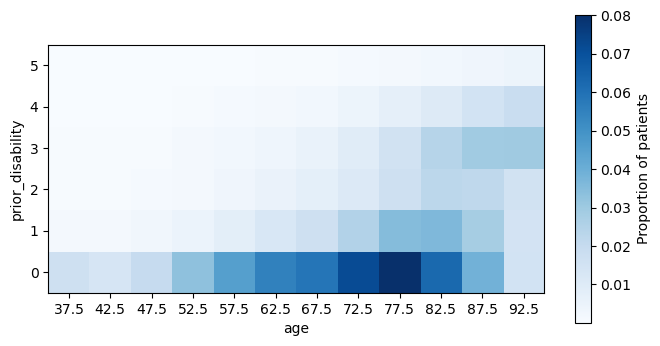

In [23]:
col1 = 'age'
col2 = 'prior_disability'

df_age_dis = grid_overlap_two(df, col1, col2)


b = df_age_dis
b = b / b.sum().sum()
# Round:
b = b.round(5)

b.iloc[0,0] += round(1.0 - b.sum().sum(), 5)
print(b.sum().sum())

b.to_csv(f'./summary_data/combo_age_disability.csv')

draw_grid(b, col1, col2, savename=f'./images/combo_age_disability.png')

df_age_dis = b

1.0


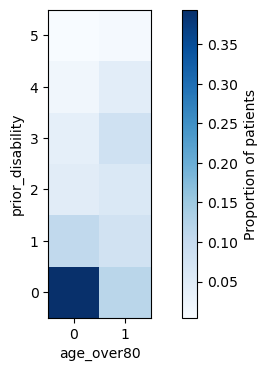

In [24]:
col1 = 'age_over80'
col2 = 'prior_disability'

df_age80_dis = grid_overlap_two(df, col1, col2)


b = df_age80_dis
b = b / b.sum().sum()
# Round:
b = b.round(5)

b.iloc[0,0] += round(1.0 - b.sum().sum(), 5)
print(b.sum().sum())

b.to_csv(f'./summary_data/combo_ageover80_disability.csv')

draw_grid(b, col1, col2, savename=f'./images/combo_ageover80_disability.png')

df_age80_dis = b

1.0


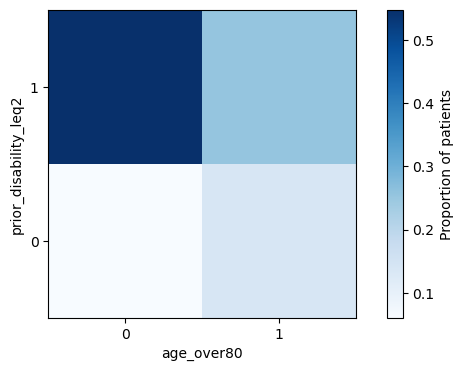

In [25]:
col1 = 'age_over80'
col2 = 'prior_disability_leq2'

df_age80_disleq2 = grid_overlap_two(df, col1, col2)


b = df_age80_disleq2
b = b / b.sum().sum()
# Round:
b = b.round(5)

b.iloc[0,0] += round(1.0 - b.sum().sum(), 5)
print(b.sum().sum())

b.to_csv(f'./summary_data/combo_ageover80_disabilityleq2.csv')

draw_grid(b, col1, col2, savename=f'./images/combo_ageover80_disabilityleq2.png')

df_age80_disleq2 = b

1.0


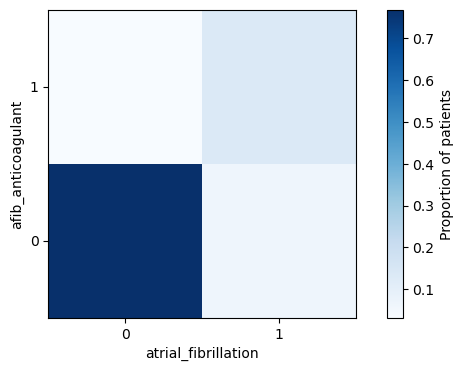

In [24]:
col1 = 'atrial_fibrillation'
col2 = 'afib_anticoagulant'

df_af_anticoag = grid_overlap_two(df, col1, col2)


b = df_af_anticoag
b = b / b.sum().sum()
# Round:
b = b.round(5)

b.iloc[0,0] += round(1.0 - b.sum().sum(), 5)

print(b.sum().sum())

b.to_csv(f'./summary_data/combo_anticoag_afib.csv')

draw_grid(b, col1, col2, savename=f'./images/combo_anticoag_afib.png')

df_af_anticoag = b

1.0


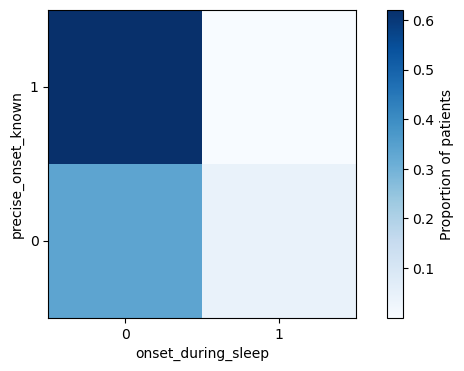

In [27]:
col1 = 'onset_during_sleep'
col2 = 'precise_onset_known'

df_sleep_precise = grid_overlap_two(df, col1, col2)


b = df_sleep_precise
b = b / b.sum().sum()
# Round:
b = b.round(5)

b.iloc[0,0] += round(1.0 - b.sum().sum(), 5)
b = b.round(5)
print(b.sum().sum())

b.to_csv(f'./summary_data/combo_sleep_precise.csv')

draw_grid(b, col1, col2, savename=f'./images/combo_sleep_precise.png')

df_sleep_precise = b

In [ ]:
cols_bar = ['stroke_team', 'stroke_severity', 'onset_during_sleep',
            'precise_onset_known', 'atrial_fibrillation',
            'afib_anticoagulant', 'prior_disability', 'thrombolysis',
            'discharge_disability', 'age',
            # Simplified columns:
            'age_over80', 'prior_disability_leq2', 'discharge_disability_leq2',
            'stroke_severity_mild', 'stroke_severity_mod', 'stroke_severity_sev',
           ]
cols_hist = ['arrival_to_scan_time']

1.0


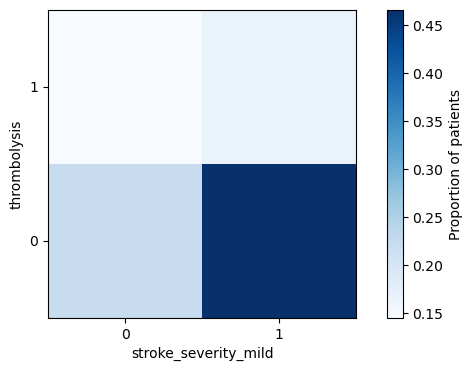

In [14]:
col1 = 'stroke_severity_mild'
col2 = 'thrombolysis'

df_mild_thromb = grid_overlap_two(df, col1, col2)


b = df_mild_thromb
b = b / b.sum().sum()
# Round:
b = b.round(5)

b.iloc[0,0] += round(1.0 - b.sum().sum(), 5)
b = b.round(5)
print(b.sum().sum())

b.to_csv(f'./summary_data/combo_mild_thrombolysis.csv')

draw_grid(b, col1, col2, savename=f'./images/combo_mild_thrombolysis.png')

df_mild_thromb = b

In [20]:
df_mild_thromb / df_mild_thromb.sum(axis='rows')

stroke_severity_mild,0,1
thrombolysis,,
0,0.604917,0.737311
1,0.395083,0.262689


1.0


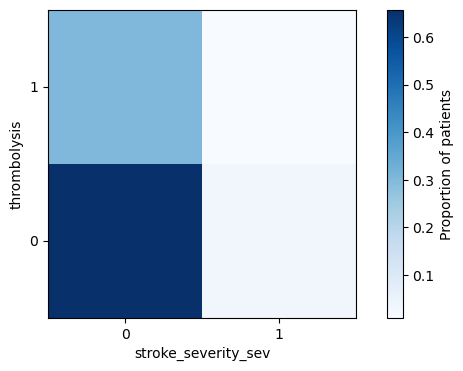

In [15]:
col1 = 'stroke_severity_sev'
col2 = 'thrombolysis'

df_sev_thromb = grid_overlap_two(df, col1, col2)


b = df_sev_thromb
b = b / b.sum().sum()
# Round:
b = b.round(5)

b.iloc[0,0] += round(1.0 - b.sum().sum(), 5)
b = b.round(5)
print(b.sum().sum())

b.to_csv(f'./summary_data/combo_severe_thrombolysis.csv')

draw_grid(b, col1, col2, savename=f'./images/combo_severe_thrombolysis.png')

df_sev_thromb = b

In [21]:
df_sev_thromb / df_sev_thromb.sum(axis='rows')

stroke_severity_sev,0,1
thrombolysis,,
0,0.685583,0.757465
1,0.314417,0.242535


1.0


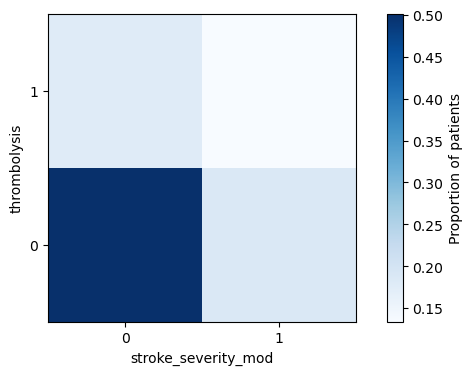

In [16]:
col1 = 'stroke_severity_mod'
col2 = 'thrombolysis'

df_mod_thromb = grid_overlap_two(df, col1, col2)


b = df_mod_thromb
b = b / b.sum().sum()
# Round:
b = b.round(5)

b.iloc[0,0] += round(1.0 - b.sum().sum(), 5)
b = b.round(5)
print(b.sum().sum())

b.to_csv(f'./summary_data/combo_moderate_thrombolysis.csv')

draw_grid(b, col1, col2, savename=f'./images/combo_moderate_thrombolysis.png')

df_mod_thromb = b

In [22]:
df_mod_thromb / df_mod_thromb.sum(axis='rows')

stroke_severity_mod,0,1
thrombolysis,,
0,0.73865,0.58255
1,0.26135,0.41745


## Arrival time for each stroke team

In [90]:
dict_for_df_time_stats = {}

n = 0
nt = 0
for i, df_here in df[['arrival_to_scan_time', 'stroke_team']].groupby('stroke_team'):
    # Use all data for this stroke team.
    mask = df_here['arrival_to_scan_time'] >0#<= 4*60
    # Pick out times, store as "t":
    t = df_here.loc[mask, 'arrival_to_scan_time']
    # Edit times of exactly zero to prevent divide by zero error for log:
    t[t==0] += 1e-5

    # Gather stats.
    # Stats for creating the lognorm:
    mu = np.log(t).mean()
    sigma = np.log(t).std()
    # Other useful stats to save:
    s = pd.Series()
    s['mean'] = t.mean()
    s['std'] = t.std()
    s['median'] = t.median()
    s['q1'] = t.quantile(0.25)
    s['q3'] = t.quantile(0.75)
    s['mu_for_lognorm'] = mu
    s['sigma_for_lognorm'] = sigma
    dict_for_df_time_stats[i] = s

    # Plot the data here with the lognorm approximation.
    # Generate new data from the lognorm:
    rng = np.random.default_rng()
    t_gen = rng.lognormal(mu, sigma, size=len(t))

    # Setup for plot:
    bins = np.arange(0, 4*60+15, 15)

    # Generate probability density function for the lognormal dist:
    # (code from docs example)
    # Add 1e-5 to prevent divide by zero warning.
    x = np.linspace(min(bins)+1e-5, max(bins), 10000)
    pdf = (np.exp(-(np.log(x) - mu)**2 / (2 * sigma**2))
           / (x * sigma * np.sqrt(2 * np.pi)))

    
    # Draw plot:
    if n == 0:
        fig, axs = plt.subplots(5, 2, figsize=(10, 20), gridspec_kw={'hspace': 0.5})
    row = n % 2
    col = n // 2
    ax = axs[col, row]
    ax.hist(t, bins=bins, density=True, label='Real data')
    # ax.hist(t_gen, bins=bins, histtype='step', density=True)

    label = rf'Lognorm ($\mu$={mu:.2f}, $\sigma$={sigma:.2f})'
    ax.plot(x, pdf, linewidth=2, color='r', label=label)

    ax.set_title(f'Team {i}')
    ax.set_xlabel('Arrival-to-scan time (minutes)')
    ax.set_ylabel('Density')
    ax.set_xlim(0, 4*60)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(30))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(15))
    ax.legend()
    
    n += 1
    if (n == 10) | (i == df['stroke_team'].sort_values().to_numpy()[-1]):
        plt.savefig(f'./images/arrival_to_scan_times_teams{nt:02}.png', bbox_inches='tight', dpi=200)
        plt.close()
        nt += 1
        n = 0

In [88]:
df_arrival_scan_time_stats = pd.concat(dict_for_df_time_stats, axis='columns')

In [92]:
df_arrival_scan_time_stats.index.name = 'stats'

In [94]:
df_arrival_scan_time_stats.round(5).to_csv('./summary_data/arrival_to_scan_time_stats_by_stroke_team.csv')